# Preprocessing & Segmentation

In [1]:
import numpy as np
import pandas as pd
import os
import joblib
import warnings
from scipy.signal import find_peaks, butter, filtfilt
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt

warnings.filterwarnings('ignore')

In [2]:

DATA_DIR = "/kaggle/input/ecg-data"
LABEL_FILE = "/kaggle/input/diagnosis/Diagnosis.xlsx"

OUTPUT_DIR = "/kaggle/working"

OUTPUT_X = os.path.join(OUTPUT_DIR, "X_preprocessed.npy")
OUTPUT_Y = os.path.join(OUTPUT_DIR, "y_preprocessed.npy")
LABEL_ENCODER_FILE = os.path.join(OUTPUT_DIR, "label_encoder_location.joblib")

In [3]:
SAMPLING_RATE = 500 # Hz
WINDOW_BEFORE_R = 300 
WINDOW_AFTER_R = 700  
TOTAL_WINDOW = WINDOW_BEFORE_R + WINDOW_AFTER_R # 1000 samples

# BANDPASS FILTER PARAMETERS
LOWCUT = 0.5
HIGHCUT = 40.0
FILTER_ORDER = 2

print("="*80)
print("ECG PREPROCESSING: RAW CSV -> BANDPASS -> SEGMENTED NPY")
print("="*80)

ECG PREPROCESSING: RAW CSV -> BANDPASS -> SEGMENTED NPY


In [4]:
def load_labels(label_file):
    print(f"Loading labels from: {label_file}")
    df = pd.read_excel(label_file)
    
    # Mapping Diagnosis ke 4 Kelas Utama
    class_mapping = {
        # Left Ventricular Region
        "Left_AMC": "Left_Ventricular_Region",
        "Left_LCC": "Left_Ventricular_Region", 
        "Left_RCC": "Left_Ventricular_Region",
        "Left_Summit": "Left_Ventricular_Region",
        
        # Right Ventricular Region
        "Right_LC": "Right_Ventricular_Region",
        "Right_RC": "Right_Ventricular_Region", 
        "Right_AC": "Right_Ventricular_Region",
        "Right_FreeWall": "Right_Ventricular_Region",
        
        # Outflow Tract Region
        "Right_RVOTOther": "Outflow_Tract_Region",
        "Left_LCC-RCC Ommisure": "Outflow_Tract_Region",
        
        # Septal Region
        "Right_PosteriorSeptal": "Septal_Region",
        "Right_AnteriorSeptal": "Septal_Region"
    }
    
    # Deteksi kolom diagnosis
    target_col = None
    if 'Diagnosis' in df.columns: target_col = 'Diagnosis'
    elif 'diagnosis' in df.columns: target_col = 'diagnosis'
    
    # Cek format kompleks (LeftRight + Sublocation)
    if 'LeftRight' in df.columns and 'Sublocation' in df.columns:
        print("Mendeteksi format kolom 'LeftRight' + 'Sublocation'")
        df['Full_Location'] = df['LeftRight'].astype(str) + '_' + df['Sublocation'].astype(str)
        df['Class'] = df['Full_Location'].map(class_mapping)
    elif target_col:
        print(f"Menggunakan kolom '{target_col}'")
        df['Class'] = df[target_col].map(class_mapping)
    else:
        raise ValueError("Tidak dapat menemukan kolom diagnosis yang valid di Excel!")
    
    # Drop yang tidak punya kelas valid
    df = df.dropna(subset=['Class'])
    print(f"Total pasien valid dengan label: {len(df)}")
    print(df['Class'].value_counts())
    
    return df

In [5]:
def apply_bandpass_filter(data, lowcut, highcut, fs, order=2):
    nyquist = 0.5 * fs
    low = lowcut / nyquist
    high = highcut / nyquist
    b, a = butter(order, [low, high], btype='band')
    # Apply filter to each channel (axis 0 is time, axis 1 is channels)
    # filtfilt applies backward-forward filter to avoid phase shift
    y = filtfilt(b, a, data, axis=0) 
    return y

def normalize_signal(signal):
    # Z-Score Normalization per lead
    mean = np.mean(signal, axis=0)
    std = np.std(signal, axis=0)
    std[std == 0] = 1
    return (signal - mean) / std

def segment_ecg(signal, fs=500):
    # Gunakan RMS untuk deteksi peak
    rms = np.sqrt(np.mean(signal**2, axis=1))
    
    # Normalize RMS
    rms_norm = (rms - np.mean(rms)) / (np.std(rms) + 1e-8)
    
    # Find Peaks
    min_dist = int(0.6 * fs) # 600ms min distance
    peaks, _ = find_peaks(rms_norm, distance=min_dist, height=0.5, prominence=0.5)
    
    segments = []
    for peak in peaks:
        start = peak - WINDOW_BEFORE_R
        end = peak + WINDOW_AFTER_R
        
        if start >= 0 and end <= len(signal):
            seg = signal[start:end, :]
            if len(seg) == TOTAL_WINDOW:
                segments.append(seg)
                
    return segments

In [6]:
def process_files(data_dir, df_labels):
    X_all = []
    y_all = []
    
    files = [f for f in os.listdir(data_dir) if f.endswith('.csv')]
    print(f"Ditemukan {len(files)} file CSV di {data_dir}")
    
    success_count = 0
    
    for i, fname in enumerate(files):
        if (i+1)%50 == 0: print(f"Processing {i+1}/{len(files)}...")
        
        try:
            pid = int(os.path.splitext(fname)[0])
        except:
            continue
            
        label_row = None
        if 'HospitalID' in df_labels.columns:
            label_row = df_labels[df_labels['HospitalID'] == pid]
        else:
            col1 = df_labels.columns[0]
            label_row = df_labels[df_labels[col1] == pid]
            
        if len(label_row) == 0:
            continue 
            
        label_class = label_row['Class'].values[0]
        
        path = os.path.join(data_dir, fname)
        try:
            df_ecg = pd.read_csv(path)
            data = df_ecg.select_dtypes(include=[np.number]).values
            if data.shape[1] > 12: data = data[:, :12] 
            
            # 1. BANDPASS FILTER
            data_filt = apply_bandpass_filter(data, LOWCUT, HIGHCUT, SAMPLING_RATE, FILTER_ORDER)
            
            # 2. NORMALISASI
            data_norm = normalize_signal(data_filt)
            
            # 3. SEGMENTASI
            segments = segment_ecg(data_norm)
            
            if len(segments) > 0:
                X_all.extend(segments)
                y_all.extend([label_class] * len(segments))
                success_count += 1
                
        except Exception as e:
            print(f"Error processing {fname}: {e}")
            continue

    print(f"\nSelesai! Berhasil memproses {success_count} file pasien.")
    return np.array(X_all), np.array(y_all)

In [7]:
# UTAMA
if __name__ == "__main__":
    if not os.path.exists(DATA_DIR):
        print(f"ERROR: Folder data tidak ditemukan di {DATA_DIR}")
        exit()
        
    df_labels = load_labels(LABEL_FILE)
    X, y = process_files(DATA_DIR, df_labels)
    
    print(f"\nShape Data: {X.shape}")
    print(f"Shape Label: {y.shape}")
    
    # Encoding Label
    le = LabelEncoder()
    y_enc = le.fit_transform(y)
    
    # Save Label Encoder
    joblib.dump(le, LABEL_ENCODER_FILE)
    print(f"Label encoder disimpan ke {LABEL_ENCODER_FILE}")
    print(f"Kelas: {le.classes_}")
    
    # Save NPY
    np.save(OUTPUT_X, X)
    np.save(OUTPUT_Y, y_enc)
    print(f"Data disimpan ke:\n  {OUTPUT_X}\n  {OUTPUT_Y}")
    
    print("\nSIAP! Sekarang jalankan 'python RUN_ALL_COMPLETE.py'")

Loading labels from: /kaggle/input/diagnosis/Diagnosis.xlsx
Mendeteksi format kolom 'LeftRight' + 'Sublocation'
Total pasien valid dengan label: 294
Class
Right_Ventricular_Region    152
Left_Ventricular_Region      69
Septal_Region                60
Outflow_Tract_Region         13
Name: count, dtype: int64
Ditemukan 334 file CSV di /kaggle/input/ecg-data
Processing 50/334...
Processing 100/334...
Processing 150/334...
Processing 200/334...
Processing 250/334...
Processing 300/334...

Selesai! Berhasil memproses 294 file pasien.

Shape Data: (5256, 1000, 12)
Shape Label: (5256,)
Label encoder disimpan ke /kaggle/working/label_encoder_location.joblib
Kelas: ['Left_Ventricular_Region' 'Outflow_Tract_Region'
 'Right_Ventricular_Region' 'Septal_Region']
Data disimpan ke:
  /kaggle/working/X_preprocessed.npy
  /kaggle/working/y_preprocessed.npy

SIAP! Sekarang jalankan 'python RUN_ALL_COMPLETE.py'


# Model CNN - RNN Grid

In [8]:
import numpy as np
import pandas as pd
import os, time, warnings
warnings.filterwarnings('ignore')
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.metrics import *
from sklearn.preprocessing import label_binarize
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from collections import Counter

np.random.seed(42)
tf.random.set_seed(42)

2026-02-01 21:48:38.488146: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1769982518.660385      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1769982518.709529      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1769982519.138387      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1769982519.138412      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1769982519.138415      55 computation_placer.cc:177] computation placer alr

In [9]:
print("="*80)
print("CNN-RNN + ATTENTION dengan GAN ECG 1D")
print("GRID SEARCH Hyperparameter Tuning + 5-Fold CV")
print("="*80)

# HYPERPARAMETER GRID untuk tuning
PARAM_GRID = [
    # Konfigurasi 1-4: RNN Units variations
    {'RNN_UNITS': 64, 'DENSE_UNITS': [128, 64], 'LR': 0.001, 'DROPOUT': 0.3, 'DROPOUT_DENSE': 0.5},
    {'RNN_UNITS': 128, 'DENSE_UNITS': [128, 64], 'LR': 0.001, 'DROPOUT': 0.3, 'DROPOUT_DENSE': 0.5},
    {'RNN_UNITS': 256, 'DENSE_UNITS': [128, 64], 'LR': 0.001, 'DROPOUT': 0.3, 'DROPOUT_DENSE': 0.5},
    {'RNN_UNITS': 128, 'DENSE_UNITS': [256, 128, 64], 'LR': 0.001, 'DROPOUT': 0.3, 'DROPOUT_DENSE': 0.5},
    
    # Konfigurasi 5-8: Learning Rate variations
    {'RNN_UNITS': 128, 'DENSE_UNITS': [128, 64], 'LR': 0.0001, 'DROPOUT': 0.3, 'DROPOUT_DENSE': 0.5},
    {'RNN_UNITS': 128, 'DENSE_UNITS': [128, 64], 'LR': 0.0005, 'DROPOUT': 0.3, 'DROPOUT_DENSE': 0.5},
    {'RNN_UNITS': 128, 'DENSE_UNITS': [128, 64], 'LR': 0.005, 'DROPOUT': 0.3, 'DROPOUT_DENSE': 0.5},
    {'RNN_UNITS': 128, 'DENSE_UNITS': [128, 64], 'LR': 0.01, 'DROPOUT': 0.3, 'DROPOUT_DENSE': 0.5},
    
    # Konfigurasi 9-12: Dropout variations
    {'RNN_UNITS': 128, 'DENSE_UNITS': [128, 64], 'LR': 0.001, 'DROPOUT': 0.2, 'DROPOUT_DENSE': 0.4},
    {'RNN_UNITS': 128, 'DENSE_UNITS': [128, 64], 'LR': 0.001, 'DROPOUT': 0.4, 'DROPOUT_DENSE': 0.6},
    {'RNN_UNITS': 128, 'DENSE_UNITS': [128, 64], 'LR': 0.001, 'DROPOUT': 0.5, 'DROPOUT_DENSE': 0.7},
    {'RNN_UNITS': 128, 'DENSE_UNITS': [128, 64], 'LR': 0.001, 'DROPOUT': 0.3, 'DROPOUT_DENSE': 0.3},
    
    # Konfigurasi 13-16: CNN Filter variations
    {'RNN_UNITS': 128, 'DENSE_UNITS': [128, 64], 'LR': 0.001, 'DROPOUT': 0.3, 'DROPOUT_DENSE': 0.5, 
     'CNN_FILTERS': [32, 64, 128]},
    {'RNN_UNITS': 128, 'DENSE_UNITS': [128, 64], 'LR': 0.001, 'DROPOUT': 0.3, 'DROPOUT_DENSE': 0.5,
     'CNN_FILTERS': [64, 128, 256]},
    {'RNN_UNITS': 128, 'DENSE_UNITS': [128, 64], 'LR': 0.001, 'DROPOUT': 0.3, 'DROPOUT_DENSE': 0.5,
     'CNN_FILTERS': [128, 256, 512]},
    {'RNN_UNITS': 128, 'DENSE_UNITS': [128, 64], 'LR': 0.001, 'DROPOUT': 0.3, 'DROPOUT_DENSE': 0.5,
     'CNN_FILTERS': [64, 128, 128]},
]

# Fixed parameters
BATCH = 32
EPOCHS_GRID = 30  # Epoch lebih sedikit untuk grid search
EPOCHS_FINAL = 50  # Epoch lebih banyak untuk final training
FOLDS = 5

# GAN PARAMETERS
LATENT_DIM = 100
GAN_EPOCHS = 300  # Lebih sedikit untuk grid search
GAN_BATCH = 32

CNN-RNN + ATTENTION dengan GAN ECG 1D
GRID SEARCH Hyperparameter Tuning + 5-Fold CV


In [10]:
class AttentionLayer(keras.layers.Layer):
    def __init__(self, **kwargs):
        super(AttentionLayer, self).__init__(**kwargs)
    def build(self, input_shape):
        self.W = self.add_weight(name='attention_weight',
                                 shape=(input_shape[-1], input_shape[-1]),
                                 initializer='glorot_uniform',
                                 trainable=True)
        self.b = self.add_weight(name='attention_bias',
                                 shape=(input_shape[-1],),
                                 initializer='zeros',
                                 trainable=True)
        super(AttentionLayer, self).build(input_shape)
    def call(self, inputs):
        e = tf.nn.tanh(tf.tensordot(inputs, self.W, axes=1) + self.b)
        a = tf.nn.softmax(e, axis=1)
        return tf.reduce_sum(inputs * a, axis=1)

In [11]:
# ====================== UTILITY FUNCTIONS ======================
def plot_confusion_matrix_complete(y_true, y_pred, classes, filename, title):
    """Plot confusion matrix lengkap"""
    cm = confusion_matrix(y_true, y_pred)
    acc = accuracy_score(y_true, y_pred)
    
    plt.figure(figsize=(12, 10))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=classes, yticklabels=classes)
    plt.title(f'{title}\nAccuracy: {acc:.4f}', fontsize=16, fontweight='bold', pad=20)
    plt.ylabel('True Label', fontsize=14, fontweight='bold')
    plt.xlabel('Predicted Label', fontsize=14, fontweight='bold')
    plt.xticks(rotation=45, ha='right')
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.savefig(filename, dpi=300, bbox_inches='tight')
    plt.close()
    
    return cm, acc

def plot_roc_curve_complete(y_true, y_pred_probs, classes, filename, title):
    """Plot ROC curve untuk semua kelas"""
    n_classes = len(classes)
    y_true_bin = label_binarize(y_true, classes=range(n_classes))
    
    plt.figure(figsize=(10, 8))
    
    # Compute ROC curve and AUC for each class
    fpr, tpr, roc_auc = {}, {}, {}
    for i in range(n_classes):
        fpr[i], tpr[i], _ = roc_curve(y_true_bin[:, i], y_pred_probs[:, i])
        roc_auc[i] = auc(fpr[i], tpr[i])
    
    # Plot all ROC curves
    colors = plt.cm.Set1(np.linspace(0, 1, n_classes))
    for i, color in zip(range(n_classes), colors):
        plt.plot(fpr[i], tpr[i], color=color, lw=2,
                 label=f'{classes[i]} (AUC = {roc_auc[i]:.3f})')
    
    plt.plot([0, 1], [0, 1], 'k--', lw=2)
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate', fontsize=12, fontweight='bold')
    plt.ylabel('True Positive Rate', fontsize=12, fontweight='bold')
    plt.title(f'{title}\nROC Curves', fontsize=14, fontweight='bold')
    plt.legend(loc="lower right", fontsize=10)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(filename, dpi=300, bbox_inches='tight')
    plt.close()

def plot_learning_curve_complete(history, filename):
    """Plot learning curve dari training history"""
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    
    # Plot accuracy
    ax1.plot(history.history['accuracy'], label='Train Accuracy', linewidth=2)
    ax1.plot(history.history['val_accuracy'], label='Val Accuracy', linewidth=2)
    ax1.set_title('Model Accuracy', fontsize=14, fontweight='bold')
    ax1.set_xlabel('Epoch', fontsize=12, fontweight='bold')
    ax1.set_ylabel('Accuracy', fontsize=12, fontweight='bold')
    ax1.legend(fontsize=10)
    ax1.grid(True, alpha=0.3)
    
    # Plot loss
    ax2.plot(history.history['loss'], label='Train Loss', linewidth=2)
    ax2.plot(history.history['val_loss'], label='Val Loss', linewidth=2)
    ax2.set_title('Model Loss', fontsize=14, fontweight='bold')
    ax2.set_xlabel('Epoch', fontsize=12, fontweight='bold')
    ax2.set_ylabel('Loss', fontsize=12, fontweight='bold')
    ax2.legend(fontsize=10)
    ax2.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig(filename, dpi=300, bbox_inches='tight')
    plt.close()

In [12]:
def plot_tsne_complete(model, X_test, y_test, classes, filename, title):
    """Plot t-SNE visualization"""
    try:
        # Create feature extractor model (ambil layer sebelum output)
        feature_layer = model.layers[-3]  # Layer sebelum output
        feature_extractor = keras.Model(
            inputs=model.input,
            outputs=feature_layer.output
        )
        
        # Extract features
        features = feature_extractor.predict(X_test, verbose=0)
        
        # Apply t-SNE
        tsne = TSNE(n_components=2, random_state=42, perplexity=30, n_iter=1000)
        features_2d = tsne.fit_transform(features)
        
        plt.figure(figsize=(12, 10))
        scatter = plt.scatter(features_2d[:, 0], features_2d[:, 1], 
                             c=y_test, cmap='tab10', s=50, alpha=0.7)
        
        plt.title(f'{title} - t-SNE Visualization', fontsize=16, fontweight='bold', pad=20)
        plt.xlabel('t-SNE Component 1', fontsize=12, fontweight='bold')
        plt.ylabel('t-SNE Component 2', fontsize=12, fontweight='bold')
        
        # Create legend
        handles, labels = scatter.legend_elements()
        plt.legend(handles, classes, title="Classes", 
                  loc="upper right", fontsize=10, title_fontsize=12)
        
        plt.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.savefig(filename, dpi=300, bbox_inches='tight')
        plt.close()
    except Exception as e:
        print(f"t-SNE plot error: {e}")

def plot_attention_maps_complete(model, X_test, y_test, classes, filename):
    """Plot attention maps"""
    try:
        # Find attention layer
        attention_layer = None
        for layer in model.layers:
            if 'attention' in layer.name.lower():
                attention_layer = layer
                break
        
        if attention_layer:
            # Create model to get attention weights
            attention_model = keras.Model(
                inputs=model.input,
                outputs=attention_layer.output
            )
            
            # Get sample data
            sample_idx = np.random.choice(len(X_test), min(5, len(X_test)), replace=False)
            X_sample = X_test[sample_idx]
            
            # Get attention weights
            attention_weights = attention_model.predict(X_sample, verbose=0)
            
            fig, axes = plt.subplots(len(X_sample), 1, figsize=(12, 3*len(X_sample)))
            if len(X_sample) == 1:
                axes = [axes]
            
            for i, (ax, x, weights) in enumerate(zip(axes, X_sample, attention_weights)):
                # Plot ECG signal (gunakan lead pertama)
                time_axis = np.arange(len(x))
                ax.plot(time_axis, x[:, 0], 'b-', alpha=0.7, label='ECG Signal')
                
                # Overlay attention weights (normalized)
                weights_norm = (weights - weights.min()) / (weights.max() - weights.min() + 1e-8)
                ax.fill_between(time_axis, x[:, 0].min(), x[:, 0].max(), 
                               where=weights_norm > 0.5, alpha=0.3, color='red',
                               label='High Attention')
                
                ax.set_title(f'Sample {i+1} - Class: {classes[y_test[sample_idx[i]]]}', 
                           fontsize=10, fontweight='bold')
                ax.set_xlabel('Time Steps')
                ax.set_ylabel('Amplitude')
                ax.legend(fontsize=8)
                ax.grid(True, alpha=0.3)
            
            plt.tight_layout()
            plt.savefig(filename, dpi=300, bbox_inches='tight')
            plt.close()
    except Exception as e:
        print(f"Attention map plot error: {e}")

def plot_fold_comparison(folds_results, filename):
    """Plot perbandingan performance antar fold"""
    folds = [r['Fold'] for r in folds_results]
    accuracies = [r['Accuracy'] for r in folds_results]
    f1_scores = [r['F1_Score'] for r in folds_results]
    
    x = np.arange(len(folds))
    width = 0.35
    
    plt.figure(figsize=(12, 6))
    plt.bar(x - width/2, accuracies, width, label='Accuracy', alpha=0.8, color='skyblue')
    plt.bar(x + width/2, f1_scores, width, label='F1-Score', alpha=0.8, color='lightcoral')
    
    plt.xlabel('Fold', fontsize=14, fontweight='bold')
    plt.ylabel('Score', fontsize=14, fontweight='bold')
    plt.title('Cross-Validation Performance Comparison', fontsize=16, fontweight='bold', pad=20)
    plt.xticks(x, [f'Fold {f}' for f in folds])
    plt.ylim([0, 1])
    plt.legend(fontsize=12)
    plt.grid(True, alpha=0.3, axis='y')
    
    # Add value labels
    for i, (acc, f1) in enumerate(zip(accuracies, f1_scores)):
        plt.text(i - width/2, acc + 0.02, f'{acc:.3f}', ha='center', fontsize=10, fontweight='bold')
        plt.text(i + width/2, f1 + 0.02, f'{f1:.3f}', ha='center', fontsize=10, fontweight='bold')
    
    plt.tight_layout()
    plt.savefig(filename, dpi=300, bbox_inches='tight')
    plt.close()

def plot_consistency(accuracies, filename):
    """Plot konsistensi akurasi antar fold"""
    plt.figure(figsize=(10, 6))
    
    # Plot line with markers
    plt.plot(range(1, len(accuracies) + 1), accuracies, 'o-', linewidth=3, markersize=10, 
             color='darkblue', markerfacecolor='red', markeredgewidth=2)
    
    # Plot mean line
    mean_acc = np.mean(accuracies)
    plt.axhline(y=mean_acc, color='green', linestyle='--', linewidth=2, 
                label=f'Mean: {mean_acc:.4f}')
    
    # Plot std range
    std_acc = np.std(accuracies)
    plt.fill_between(range(0, len(accuracies) + 2), 
                     mean_acc - std_acc, mean_acc + std_acc, 
                     alpha=0.2, color='green', label=f'±1 STD: {std_acc:.4f}')
    
    plt.xlabel('Fold', fontsize=14, fontweight='bold')
    plt.ylabel('Accuracy', fontsize=14, fontweight='bold')
    plt.title('Accuracy Consistency Across Folds', fontsize=16, fontweight='bold', pad=20)
    plt.xticks(range(1, len(accuracies) + 1))
    plt.ylim([0, 1])
    plt.legend(fontsize=12)
    plt.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig(filename, dpi=300, bbox_inches='tight')
    plt.close()

def save_tabel3_efficiency(model, train_times, filename):
    """Save Tabel 3 - Model Efficiency"""
    # Count trainable parameters
    trainable_params = np.sum([tf.keras.backend.count_params(w) for w in model.trainable_weights])
    
    # Calculate average time per epoch (estimate)
    avg_epoch_time = np.mean(train_times) / EPOCHS_FINAL if EPOCHS_FINAL > 0 else 0
    
    df = pd.DataFrame({
        'Metric': ['Trainable Parameters', 'Average Training Time per Fold (hours)', 
                   'Average Time per Epoch (seconds)', 'Total Training Time (hours)'],
        'Value': [trainable_params, 
                  f'{np.mean(train_times)/3600:.4f}',
                  f'{avg_epoch_time:.2f}',
                  f'{np.sum(train_times)/3600:.4f}']
    })
    df.to_csv(filename, index=False)

def save_tabel4_consistency(accuracies, filename):
    """Save Tabel 4 - Consistency Analysis"""
    mean_acc = np.mean(accuracies)
    std_acc = np.std(accuracies)
    cv = (std_acc / mean_acc) * 100 if mean_acc > 0 else 0
    
    df = pd.DataFrame({
        'Statistic': ['Mean Accuracy', 'Standard Deviation', 'Coefficient of Variation (%)',
                      'Min Accuracy', 'Max Accuracy', 'Range'],
        'Value': [f'{mean_acc:.4f}', f'{std_acc:.4f}', f'{cv:.2f}',
                  f'{np.min(accuracies):.4f}', f'{np.max(accuracies):.4f}',
                  f'{np.max(accuracies) - np.min(accuracies):.4f}']
    })
    df.to_csv(filename, index=False)

In [13]:
# ====================== GAN FUNCTIONS ======================
def normalize_for_gan(X_class):
    """Normalize untuk GAN: [-1, 1] range"""
    X_norm = X_class.copy()
    for i in range(len(X_norm)):
        sample = X_norm[i]
        min_val = np.min(sample)
        max_val = np.max(sample)
        if max_val - min_val > 0:
            X_norm[i] = (sample - min_val) / (max_val - min_val)
        else:
            X_norm[i] = sample
    X_norm = X_norm * 2 - 1
    return X_norm

def denormalize_from_gan(X_gan):
    """Convert kembali dari [-1, 1] ke original scale"""
    X_denorm = (X_gan + 1) / 2
    return X_denorm

def build_generator(latent_dim, output_dim):
    """Generator untuk ECG 1D"""
    model = keras.Sequential([
        layers.Dense(256, input_dim=latent_dim),
        layers.LeakyReLU(alpha=0.2),
        layers.BatchNormalization(),
        
        layers.Dense(512),
        layers.LeakyReLU(alpha=0.2),
        layers.BatchNormalization(),
        
        layers.Dense(1024),
        layers.LeakyReLU(alpha=0.2),
        layers.BatchNormalization(),
        
        layers.Dense(output_dim),
        layers.Activation('tanh')
    ])
    return model

def build_discriminator(input_dim):
    """Discriminator untuk ECG 1D"""
    model = keras.Sequential([
        layers.Dense(512, input_dim=input_dim),
        layers.LeakyReLU(alpha=0.2),
        layers.Dropout(0.3),
        
        layers.Dense(256),
        layers.LeakyReLU(alpha=0.2),
        layers.Dropout(0.3),
        
        layers.Dense(128),
        layers.LeakyReLU(alpha=0.2),
        layers.Dropout(0.3),
        
        layers.Dense(1, activation='sigmoid')
    ])
    model.compile(loss='binary_crossentropy',
                  optimizer=Adam(learning_rate=0.0002, beta_1=0.5),
                  metrics=['accuracy'])
    return model

def build_gan(generator, discriminator):
    """GAN Model"""
    discriminator.trainable = False
    model = keras.Sequential([
        generator,
        discriminator
    ])
    model.compile(loss='binary_crossentropy',
                  optimizer=Adam(learning_rate=0.0002, beta_1=0.5))
    return model

def train_gan_per_class(X_class_original, n_samples_needed):
    """
    Train GAN untuk satu kelas spesifik
    """
    original_shape = X_class_original.shape
    X_class_flat = X_class_original.reshape(len(X_class_original), -1)
    X_class_norm = normalize_for_gan(X_class_flat)
    
    generator = build_generator(LATENT_DIM, X_class_norm.shape[1])
    discriminator = build_discriminator(X_class_norm.shape[1])
    gan = build_gan(generator, discriminator)
    
    batch_size = min(GAN_BATCH, len(X_class_norm))
    half_batch = batch_size // 2
    
    for epoch in range(GAN_EPOCHS):
        # Train Discriminator
        idx = np.random.randint(0, len(X_class_norm), half_batch)
        real_samples = X_class_norm[idx]
        real_labels = np.ones((half_batch, 1))
        
        noise = np.random.normal(0, 1, (half_batch, LATENT_DIM))
        fake_samples = generator.predict(noise, verbose=0)
        fake_labels = np.zeros((half_batch, 1))
        
        d_loss_real = discriminator.train_on_batch(real_samples, real_labels)
        d_loss_fake = discriminator.train_on_batch(fake_samples, fake_labels)
        
        # Train Generator
        noise = np.random.normal(0, 1, (batch_size, LATENT_DIM))
        valid_labels = np.ones((batch_size, 1))
        g_loss = gan.train_on_batch(noise, valid_labels)
        
        if (epoch + 1) % 100 == 0:
            print(f"  GAN Epoch {epoch+1}/{GAN_EPOCHS} - D Loss: {0.5*np.add(d_loss_real[0], d_loss_fake[0]):.4f}, G Loss: {g_loss:.4f}")
    
    # Generate samples
    n_to_generate = n_samples_needed
    noise = np.random.normal(0, 1, (n_to_generate, LATENT_DIM))
    generated_flat = generator.predict(noise, verbose=0)
    generated_denorm = denormalize_from_gan(generated_flat)
    generated_samples = generated_denorm.reshape(-1, *original_shape[1:])
    
    return generated_samples

def balance_with_gan(X_train, y_train):
    """
    Balance dataset menggunakan GAN per kelas minoritas
    """
    print("\n=== Balancing dengan GAN ===")
    class_counts = Counter(y_train)
    max_count = max(class_counts.values())
    
    X_balanced = [X_train]
    y_balanced = [y_train]
    
    for class_id in np.unique(y_train):
        count = class_counts[class_id]
        needed = max_count - count
        
        if needed > 0:
            print(f"  Kelas {class_id}: {count} samples -> perlu {needed} samples baru")
            
            X_class = X_train[y_train == class_id]
            
            if len(X_class) < 10:
                print(f"  ⚠️  Kelas {class_id} terlalu sedikit ({len(X_class)} samples), gunakan oversampling sederhana")
                indices = np.random.choice(len(X_class), needed, replace=True)
                synthetic = X_class[indices] + np.random.normal(0, 0.01, X_class[indices].shape)
            else:
                print(f"  🏗️  Training GAN untuk kelas {class_id}...")
                synthetic = train_gan_per_class(X_class, needed)
                print(f"  ✅ Generated {len(synthetic)} samples untuk kelas {class_id}")
            
            X_balanced.append(synthetic)
            y_balanced.append(np.full(len(synthetic), class_id))
    
    X_balanced = np.vstack(X_balanced)
    y_balanced = np.concatenate(y_balanced)
    
    idx = np.random.permutation(len(X_balanced))
    X_balanced = X_balanced[idx]
    y_balanced = y_balanced[idx]
    
    print(f"  Dataset setelah balancing: {X_balanced.shape}")
    print(f"  Distribusi kelas: {dict(Counter(y_balanced))}")
    
    return X_balanced, y_balanced

In [14]:
# ====================== CNN-RNN MODEL ======================
def build_model(input_shape, num_classes, params):
    """Model CNN-RNN dengan Attention"""
    inputs = layers.Input(shape=input_shape)
    
    # Gunakan CNN filters dari params jika ada, default [64, 128, 256]
    cnn_filters = params.get('CNN_FILTERS', [64, 128, 256])
    
    # CNN Block 1
    x = layers.Conv1D(cnn_filters[0], 7, padding='same', activation='relu')(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling1D(2)(x)
    x = layers.Dropout(params['DROPOUT'])(x)
    
    # CNN Block 2
    x = layers.Conv1D(cnn_filters[1], 5, padding='same', activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling1D(2)(x)
    x = layers.Dropout(params['DROPOUT'])(x)
    
    # CNN Block 3
    x = layers.Conv1D(cnn_filters[2], 3, padding='same', activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling1D(2)(x)
    x = layers.Dropout(params['DROPOUT'])(x)
    
    # RNN Block
    x = layers.SimpleRNN(params['RNN_UNITS'], return_sequences=True, activation='tanh')(x)
    x = layers.Dropout(params['DROPOUT'])(x)
    x = layers.SimpleRNN(params['RNN_UNITS'] // 2, return_sequences=True, activation='tanh')(x)
    x = layers.Dropout(params['DROPOUT'])(x)
    
    # Attention Layer
    x = AttentionLayer()(x)
    
    # Dense Layers
    for units in params['DENSE_UNITS']:
        x = layers.Dense(units, activation='relu')(x)
        x = layers.BatchNormalization()(x)
        x = layers.Dropout(params['DROPOUT_DENSE'])(x)
    
    # Output Layer
    outputs = layers.Dense(num_classes, activation='softmax')(x)
    
    model = models.Model(inputs, outputs)
    model.compile(optimizer=Adam(params['LR']),
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])
    
    return model

In [15]:
# ====================== GRID SEARCH FUNCTION ======================
def perform_grid_search(X_train, y_train, X_val, y_val, le, param_grid):
    """
    Perform grid search untuk mencari parameter terbaik
    """
    print(f"\n{'='*80}")
    print("PERFORMING GRID SEARCH HYPERPARAMETER TUNING")
    print(f"{'='*80}")
    print(f"Testing {len(param_grid)} parameter configurations...")
    
    best_params = None
    best_accuracy = 0
    grid_results = []
    
    for i, params in enumerate(param_grid, 1):
        print(f"\n[GRID SEARCH {i}/{len(param_grid)}] Testing parameters:")
        print(f"  RNN_UNITS: {params['RNN_UNITS']}")
        print(f"  DENSE_UNITS: {params['DENSE_UNITS']}")
        print(f"  Learning Rate: {params['LR']}")
        print(f"  Dropout: {params['DROPOUT']}")
        print(f"  Dropout Dense: {params['DROPOUT_DENSE']}")
        
        if 'CNN_FILTERS' in params:
            print(f"  CNN Filters: {params['CNN_FILTERS']}")
        
        # Balance training data dengan GAN
        X_train_bal, y_train_bal = balance_with_gan(X_train, y_train)
        
        # Build and train model
        model = build_model(X_train.shape[1:], len(le.classes_), params)
        
        callbacks = [
            EarlyStopping(monitor='val_accuracy', patience=10, restore_best_weights=True, verbose=0),
            ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-6, verbose=0)
        ]
        
        # Train dengan epoch lebih sedikit untuk grid search
        history = model.fit(
            X_train_bal, y_train_bal,
            validation_data=(X_val, y_val),
            epochs=EPOCHS_GRID,
            batch_size=BATCH,
            callbacks=callbacks,
            verbose=0
        )
        
        # Evaluate
        y_pred = np.argmax(model.predict(X_val, verbose=0), axis=1)
        acc = accuracy_score(y_val, y_pred)
        f1 = f1_score(y_val, y_pred, average='weighted')
        
        print(f"  Results: Accuracy = {acc:.4f}, F1-Score = {f1:.4f}")
        
        grid_results.append({
            'Config': i,
            'Params': params,
            'Accuracy': acc,
            'F1_Score': f1
        })
        
        # Update best parameters
        if acc > best_accuracy:
            best_accuracy = acc
            best_params = params
            print(f"  🎯 New best configuration!")
    
    # Save grid search results
    grid_df = pd.DataFrame([
        {
            'Config': r['Config'],
            'RNN_UNITS': r['Params']['RNN_UNITS'],
            'DENSE_UNITS': str(r['Params']['DENSE_UNITS']),
            'LR': r['Params']['LR'],
            'DROPOUT': r['Params']['DROPOUT'],
            'DROPOUT_DENSE': r['Params']['DROPOUT_DENSE'],
            'CNN_FILTERS': str(r['Params'].get('CNN_FILTERS', [64, 128, 256])),
            'Accuracy': r['Accuracy'],
            'F1_Score': r['F1_Score']
        }
        for r in grid_results
    ])
    
    grid_df.to_csv('FINAL_Grid_Search_Results.csv', index=False)
    
    print(f"\n{'='*80}")
    print("GRID SEARCH COMPLETED!")
    print(f"{'='*80}")
    print(f"Best Accuracy: {best_accuracy:.4f}")
    print(f"Best Parameters:")
    print(f"  RNN_UNITS: {best_params['RNN_UNITS']}")
    print(f"  DENSE_UNITS: {best_params['DENSE_UNITS']}")
    print(f"  Learning Rate: {best_params['LR']}")
    print(f"  Dropout: {best_params['DROPOUT']}")
    print(f"  Dropout Dense: {best_params['DROPOUT_DENSE']}")
    
    if 'CNN_FILTERS' in best_params:
        print(f"  CNN Filters: {best_params['CNN_FILTERS']}")
    
    return best_params, best_accuracy, grid_df

Loading preprocessed data...
Data shape: (5256, 1000, 12)
Label shape: (5256,)
Classes: ['Left_Ventricular_Region' 'Outflow_Tract_Region'
 'Right_Ventricular_Region' 'Septal_Region']

Data split for Grid Search:
  Grid Train: (3153, 1000, 12)
  Grid Val:   (1051, 1000, 12)
  Final Test: (1052, 1000, 12)

PERFORMING GRID SEARCH HYPERPARAMETER TUNING
Testing 16 parameter configurations...

[GRID SEARCH 1/16] Testing parameters:
  RNN_UNITS: 64
  DENSE_UNITS: [128, 64]
  Learning Rate: 0.001
  Dropout: 0.3
  Dropout Dense: 0.5

=== Balancing dengan GAN ===
  Kelas 0: 718 samples -> perlu 869 samples baru
  🏗️  Training GAN untuk kelas 0...


I0000 00:00:1769982532.604808      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1769982532.610860      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5
I0000 00:00:1769982534.183371     122 service.cc:152] XLA service 0x79df28003a20 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1769982534.183403     122 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1769982534.183407     122 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1769982534.287949     122 cuda_dnn.cc:529] Loaded cuDNN version 91002
I0000 00:00:1769982534.865507     122 device_compiler.h:188] Compiled clust

  GAN Epoch 100/300 - D Loss: 1.0729, G Loss: 0.2118
  GAN Epoch 200/300 - D Loss: 1.6378, G Loss: 0.1195
  GAN Epoch 300/300 - D Loss: 2.2192, G Loss: 0.0838
  ✅ Generated 869 samples untuk kelas 0
  Kelas 1: 126 samples -> perlu 1461 samples baru
  🏗️  Training GAN untuk kelas 1...
  GAN Epoch 100/300 - D Loss: 1.0701, G Loss: 0.1110
  GAN Epoch 200/300 - D Loss: 1.7220, G Loss: 0.0607
  GAN Epoch 300/300 - D Loss: 2.3866, G Loss: 0.0420
  ✅ Generated 1461 samples untuk kelas 1
  Kelas 3: 722 samples -> perlu 865 samples baru
  🏗️  Training GAN untuk kelas 3...
  GAN Epoch 100/300 - D Loss: 1.0511, G Loss: 0.2822
  GAN Epoch 200/300 - D Loss: 1.5724, G Loss: 0.1625
  GAN Epoch 300/300 - D Loss: 2.1350, G Loss: 0.1149
  ✅ Generated 865 samples untuk kelas 3
  Dataset setelah balancing: (6348, 1000, 12)
  Distribusi kelas: {np.int64(0): 1587, np.int64(2): 1587, np.int64(1): 1587, np.int64(3): 1587}
  Results: Accuracy = 0.7279, F1-Score = 0.7025
  🎯 New best configuration!

[GRID SEARC

✓ 7. Consistency Plot saved
✓ 8. Best Model saved
✓ 9. CV Results CSV saved
✓ 10. Tabel 1 saved
✓ 11. Tabel 2 saved
✓ 12. Tabel 3 saved
✓ 13. Tabel 4 saved

ALL 13 OUTPUTS COMPLETED FOR CNN_RNN_GAN_GRID!
Model: CNN-RNN with Attention and GAN (Grid Search Tuned)
Grid Search Best Accuracy: 0.8430
5-Fold CV Best Accuracy: 0.8639 (Fold 5)
5-Fold CV Mean Accuracy: 0.7945 ± 0.0521
Best Parameters:
  RNN Units: 128
  Dense Units: [128, 64]
  Learning Rate: 0.001
  Dropout: 0.3
  Dropout Dense: 0.3
Total Time: 1.93 hours

📁 16 Output Files Generated:
  1. FINAL_CM_CNN_RNN_GAN_GRID.png          - Confusion Matrix
  2. FINAL_ROC_CNN_RNN_GAN_GRID.png         - ROC Curve
  3. FINAL_Learning_Curve_CNN_RNN_GAN_GRID.png - Learning Curve
  4. FINAL_TSNE_CNN_RNN_GAN_GRID.png        - t-SNE Visualization
  5. FINAL_Attention_CNN_RNN_GAN_GRID.png   - Attention Maps
  6. FINAL_Fold_Comparison_CNN_RNN_GAN_GRID.png - Fold Comparison
  7. FINAL_Consistency_CNN_RNN_GAN_GRID.png - Consistency Plot
  8. FINAL_b

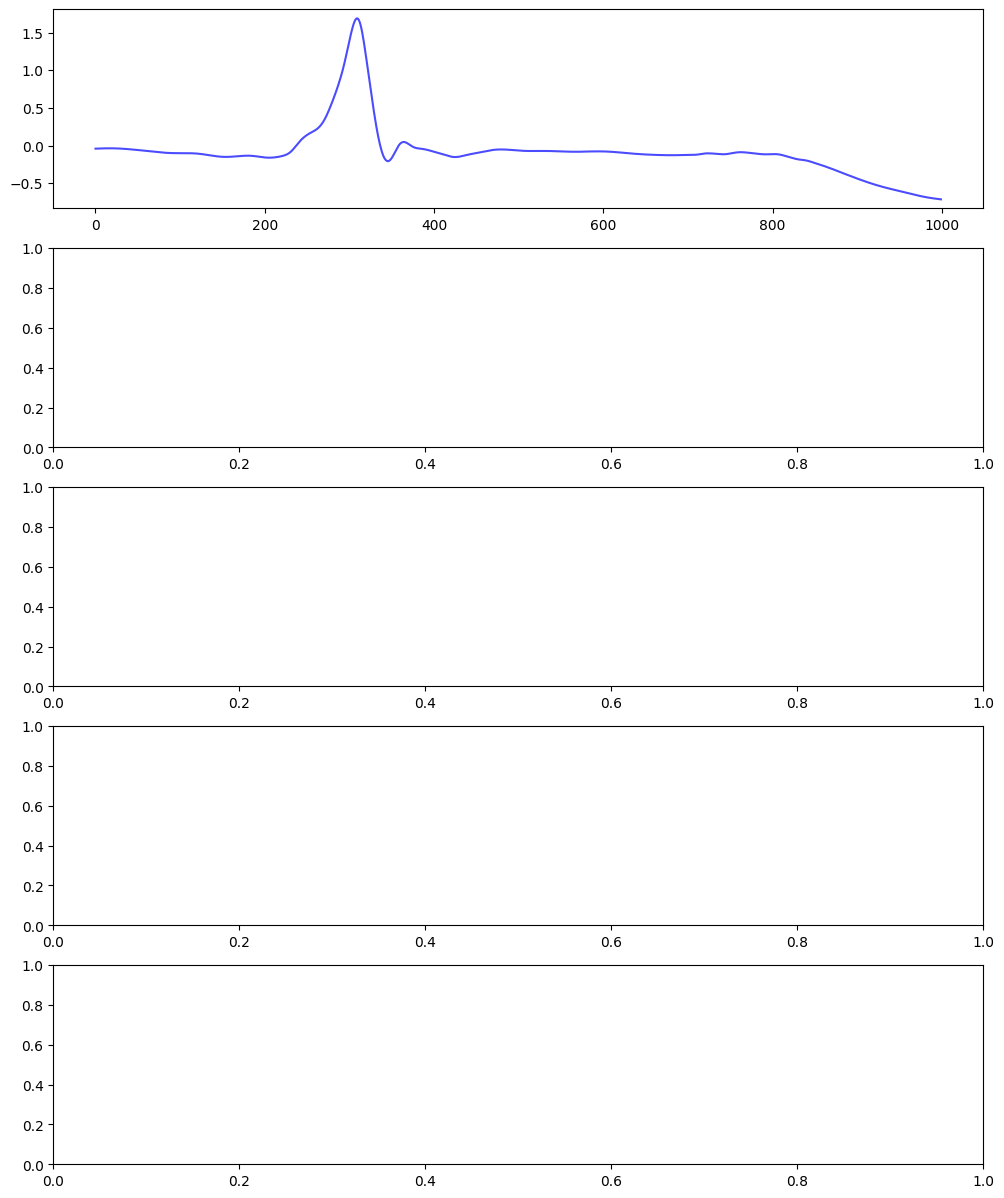

In [16]:
# ====================== MAIN FUNCTION ======================
def main():
    start_total = time.time()
    MODEL_NAME = "CNN_RNN_GAN_GRID"
    
    # Load data
    print("Loading preprocessed data...")
    X = np.load('X_preprocessed.npy')
    y = np.load('y_preprocessed.npy')
    le = joblib.load('label_encoder_location.joblib')
    
    print(f"Data shape: {X.shape}")
    print(f"Label shape: {y.shape}")
    print(f"Classes: {le.classes_}")
    
    # Step 1: Split data untuk Grid Search (80% train, 20% validation)
    X_temp, X_test_final, y_temp, y_test_final = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
    )
    
    # Step 2: Split lagi untuk Grid Search (60% train, 20% validation)
    X_train_grid, X_val_grid, y_train_grid, y_val_grid = train_test_split(
        X_temp, y_temp, test_size=0.25, random_state=42, stratify=y_temp  # 0.25 * 0.8 = 0.2
    )
    
    print(f"\nData split for Grid Search:")
    print(f"  Grid Train: {X_train_grid.shape}")
    print(f"  Grid Val:   {X_val_grid.shape}")
    print(f"  Final Test: {X_test_final.shape}")
    
    # Step 3: Perform Grid Search
    best_params, best_grid_acc, grid_results = perform_grid_search(
        X_train_grid, y_train_grid, X_val_grid, y_val_grid, le, PARAM_GRID
    )
    
    # Save best parameters
    pd.DataFrame([best_params]).to_csv('FINAL_Best_Parameters.csv', index=False)
    
    # Step 4: 5-Fold CV dengan parameter terbaik
    print(f"\n{'='*80}")
    print("5-FOLD CROSS VALIDATION WITH BEST PARAMETERS")
    print(f"{'='*80}")
    
    # Gunakan semua data untuk 5-fold CV
    skf = StratifiedKFold(n_splits=FOLDS, shuffle=True, random_state=42)
    results = []
    best_model = None
    best_accuracy = 0
    best_fold_idx = 0
    best_history = None
    fold_data = []  # Simpan data tiap fold
    
    for fold, (train_idx, test_idx) in enumerate(skf.split(X, y), 1):
        fold_start = time.time()
        print(f"\n{'='*60}")
        print(f"FOLD {fold}/{FOLDS} with Best Parameters")
        print(f"{'='*60}")
        
        # Split data
        X_train, X_test = X[train_idx], X[test_idx]
        y_train, y_test = y[train_idx], y[test_idx]
        
        print(f"Train shape: {X_train.shape}, Test shape: {X_test.shape}")
        print(f"Train distribution: {dict(Counter(y_train))}")
        
        # Balance dengan GAN
        X_train_bal, y_train_bal = balance_with_gan(X_train, y_train)
        
        # Build dan train model dengan best parameters
        model = build_model(X.shape[1:], len(le.classes_), best_params)
        
        callbacks = [
            EarlyStopping(monitor='val_accuracy', patience=15, restore_best_weights=True, verbose=0),
            ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-6, verbose=0)
        ]
        
        print("\nTraining CNN-RNN model with best parameters...")
        history = model.fit(
            X_train_bal, y_train_bal,
            validation_split=0.2,
            epochs=EPOCHS_FINAL,
            batch_size=BATCH,
            callbacks=callbacks,
            verbose=1
        )
        
        # Evaluate
        y_pred = np.argmax(model.predict(X_test, verbose=0), axis=1)
        acc = accuracy_score(y_test, y_pred)
        f1 = f1_score(y_test, y_pred, average='weighted')
        fold_time = time.time() - fold_start
        
        print(f"Fold {fold} Results:")
        print(f"  Accuracy:  {acc:.4f}")
        print(f"  F1-Score:  {f1:.4f}")
        print(f"  Time:      {fold_time/60:.2f} minutes")
        
        fold_result = {
            'Fold': fold,
            'Accuracy': acc,
            'F1_Score': f1,
            'Train_Time': fold_time
        }
        results.append(fold_result)
        
        # Simpan data fold
        fold_data.append({
            'X_test': X_test,
            'y_test': y_test,
            'history': history
        })
        
        # Update best model
        if acc > best_accuracy:
            best_accuracy = acc
            best_model = model
            best_fold_idx = fold - 1
            best_history = history
            print(f"  🏆 New best model! Accuracy: {acc:.4f}")
    
    # ====================== OUTPUT LENGKAP ======================
    print(f"\n{'='*60}")
    print("GENERATING 13 OUTPUT FILES...")
    print(f"{'='*60}")
    
    # Retrieve test data from the fold that produced best model
    best_fold_data = fold_data[best_fold_idx]
    best_X_test = best_fold_data['X_test']
    best_y_test = best_fold_data['y_test']
    
    y_pred_probs = best_model.predict(best_X_test, verbose=0)
    y_pred = np.argmax(y_pred_probs, axis=1)
    
    # 1. Confusion Matrix
    plot_confusion_matrix_complete(best_y_test, y_pred, le.classes_, 
                                  f'FINAL_CM_{MODEL_NAME}.png', f'{MODEL_NAME} CM')
    print("✓ 1. Confusion Matrix saved")
    
    # 2. ROC Curve
    plot_roc_curve_complete(best_y_test, y_pred_probs, le.classes_, 
                           f'FINAL_ROC_{MODEL_NAME}.png', f'{MODEL_NAME} ROC')
    print("✓ 2. ROC Curve saved")
    
    # 3. Learning Curve
    plot_learning_curve_complete(best_history, f'FINAL_Learning_Curve_{MODEL_NAME}.png')
    print("✓ 3. Learning Curve saved")
    
    # 4. t-SNE Visualization
    plot_tsne_complete(best_model, best_X_test, best_y_test, le.classes_, 
                      f'FINAL_TSNE_{MODEL_NAME}.png', f'{MODEL_NAME}')
    print("✓ 4. t-SNE saved")
    
    # 5. Attention Maps
    plot_attention_maps_complete(best_model, best_X_test, best_y_test, le.classes_, 
                                f'FINAL_Attention_{MODEL_NAME}.png')
    print("✓ 5. Attention Maps saved")
    
    # 6. Fold Comparison
    plot_fold_comparison(results, f'FINAL_Fold_Comparison_{MODEL_NAME}.png')
    print("✓ 6. Fold Comparison saved")
    
    # 7. Consistency Plot
    accs = [r['Accuracy'] for r in results]
    plot_consistency(accs, f'FINAL_Consistency_{MODEL_NAME}.png')
    print("✓ 7. Consistency Plot saved")
    
    # 8. Save Best Model
    best_model.save(f'FINAL_best_model_{MODEL_NAME}.h5')
    print("✓ 8. Best Model saved")
    
    # 9. CV Results CSV
    pd.DataFrame(results).to_csv(f'FINAL_CV_{MODEL_NAME}.csv', index=False)
    print("✓ 9. CV Results CSV saved")
    
    # 10. Tabel 1 - Summary Metrics
    df_t1 = pd.DataFrame({
        'Metric': ['Mean Accuracy', 'Best Accuracy', 'Mean F1'],
        'Value': [np.mean(accs), best_accuracy, np.mean([r['F1_Score'] for r in results])]
    })
    df_t1.to_csv(f'FINAL_Tabel1_{MODEL_NAME}.csv', index=False)
    print("✓ 10. Tabel 1 saved")
    
    # 11. Tabel 2 - Per Class Metrics
    prec, rec, f1_s, supp = precision_recall_fscore_support(best_y_test, y_pred, 
                                                           average=None, zero_division=0)
    per_class_acc = []
    for c in range(len(le.classes_)):
        mask = (best_y_test == c)
        if np.sum(mask) > 0: 
            per_class_acc.append(accuracy_score(best_y_test[mask], y_pred[mask]))
        else: 
            per_class_acc.append(0.0)
    
    df_t2 = pd.DataFrame({
        'Kelas': le.classes_,
        'Akurasi': per_class_acc,
        'Recall': rec,
        'Precision': prec,
        'F1-Score': f1_s,
        'Support': supp
    })
    df_t2.to_csv(f'FINAL_Tabel2_{MODEL_NAME}.csv', index=False)
    print("✓ 11. Tabel 2 saved")
    
    # 12. Tabel 3 - Efficiency
    times = [r['Train_Time'] for r in results]
    save_tabel3_efficiency(best_model, times, f'FINAL_Tabel3_{MODEL_NAME}.csv')
    print("✓ 12. Tabel 3 saved")
    
    # 13. Tabel 4 - Consistency
    save_tabel4_consistency(accs, f'FINAL_Tabel4_{MODEL_NAME}.csv')
    print("✓ 13. Tabel 4 saved")
    
    # Additional: Save Grid Search Summary
    grid_summary = {
        'Best_Grid_Accuracy': best_grid_acc,
        'Best_RNN_UNITS': best_params['RNN_UNITS'],
        'Best_DENSE_UNITS': str(best_params['DENSE_UNITS']),
        'Best_Learning_Rate': best_params['LR'],
        'Best_Dropout': best_params['DROPOUT'],
        'Best_Dropout_Dense': best_params['DROPOUT_DENSE'],
        'Final_Mean_Accuracy': np.mean(accs),
        'Final_Best_Accuracy': best_accuracy
    }
    
    pd.DataFrame([grid_summary]).to_csv('FINAL_Grid_Search_Summary.csv', index=False)
    
    print(f"\n{'='*60}")
    print(f"ALL 13 OUTPUTS COMPLETED FOR {MODEL_NAME}!")
    print(f"{'='*60}")
    print(f"Model: CNN-RNN with Attention and GAN (Grid Search Tuned)")
    print(f"Grid Search Best Accuracy: {best_grid_acc:.4f}")
    print(f"5-Fold CV Best Accuracy: {best_accuracy:.4f} (Fold {best_fold_idx + 1})")
    print(f"5-Fold CV Mean Accuracy: {np.mean(accs):.4f} ± {np.std(accs):.4f}")
    print(f"Best Parameters:")
    print(f"  RNN Units: {best_params['RNN_UNITS']}")
    print(f"  Dense Units: {best_params['DENSE_UNITS']}")
    print(f"  Learning Rate: {best_params['LR']}")
    print(f"  Dropout: {best_params['DROPOUT']}")
    print(f"  Dropout Dense: {best_params['DROPOUT_DENSE']}")
    if 'CNN_FILTERS' in best_params:
        print(f"  CNN Filters: {best_params['CNN_FILTERS']}")
    print(f"Total Time: {(time.time() - start_total)/3600:.2f} hours")
    
    print(f"\n📁 16 Output Files Generated:")
    print("  1. FINAL_CM_CNN_RNN_GAN_GRID.png          - Confusion Matrix")
    print("  2. FINAL_ROC_CNN_RNN_GAN_GRID.png         - ROC Curve")
    print("  3. FINAL_Learning_Curve_CNN_RNN_GAN_GRID.png - Learning Curve")
    print("  4. FINAL_TSNE_CNN_RNN_GAN_GRID.png        - t-SNE Visualization")
    print("  5. FINAL_Attention_CNN_RNN_GAN_GRID.png   - Attention Maps")
    print("  6. FINAL_Fold_Comparison_CNN_RNN_GAN_GRID.png - Fold Comparison")
    print("  7. FINAL_Consistency_CNN_RNN_GAN_GRID.png - Consistency Plot")
    print("  8. FINAL_best_model_CNN_RNN_GAN_GRID.h5   - Best Model")
    print("  9. FINAL_CV_CNN_RNN_GAN_GRID.csv          - CV Results")
    print(" 10. FINAL_Tabel1_CNN_RNN_GAN_GRID.csv      - Summary Metrics")
    print(" 11. FINAL_Tabel2_CNN_RNN_GAN_GRID.csv      - Per Class Metrics")
    print(" 12. FINAL_Tabel3_CNN_RNN_GAN_GRID.csv      - Efficiency Analysis")
    print(" 13. FINAL_Tabel4_CNN_RNN_GAN_GRID.csv      - Consistency Analysis")
    print(" 14. FINAL_Grid_Search_Results.csv          - Grid Search Results")
    print(" 15. FINAL_Best_Parameters.csv              - Best Parameters")
    print(" 16. FINAL_Grid_Search_Summary.csv          - Grid Search Summary")
    print(f"\n✅ CNN-RNN with GAN Grid Search Implementation COMPLETE!")

if __name__ == "__main__":
    main()